# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 06: Classificação**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_06_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# <font color='green'><u><b>Parte 1 - Classificação Binária</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Iranian Churn Dataset (2020). UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C5JW3Z</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/563/iranian+churn+dataset</font>

**Resposta:** O dataset possui informações sobre o churn de uma empresa iraniana de telecomunicações. O objetivo é a predição do churn e inclui classificação, usando o churn como variável alvo, e regressão usando alguma outra feature como variável alvo. Ele possui informações como falha em ligações, o quanto era cobrado, frequência de uso, frequência de SMS, idade, tarifa do plano e outras características de uso do tipo inteiro e binário, usados para prever a coluna binária churn em problemas de classificação e outras features em problemas de regressão.

In [ ]:
# fetch dataset
ds = fetch_ucirepo(id=563)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns')

{'uci_id': 563,
 'name': 'Iranian Churn',
 'repository_url': 'https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/563/data.csv',
 'abstract': "This dataset is randomly collected from an Iranian telecom company's database over a period of 12 months.",
 'area': 'Business',
 'tasks': ['Classification', 'Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 3150,
 'num_features': 13,
 'feature_types': ['Integer'],
 'demographics': ['Age'],
 'target_col': ['Churn'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5JW3Z',
 'creators': [],
 'intro_paper': None,
 'additional_info': {'summary': 'This dataset is randomly collected from an Iranian telecom companyâ€™s database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13

,name,role,type,demographic,description,units,missing_values
0,Call Failure,Feature,Integer,None,None,None,no
1,Complains,Feature,Binary,None,None,None,no
2,Subscription Length,Feature,Integer,None,None,None,no
3,Charge Amount,Feature,Integer,None,None,None,no
4,Seconds of Use,Feature,Integer,None,None,None,no
5,Frequency of use,Feature,Integer,None,None,None,no
6,Frequency of SMS,Feature,Integer,None,None,None,no
7,Distinct Called Numbers,Feature,Integer,None,None,None,no
8,Age Group,Feature,Integer,Age,None,None,no
9,Tariff Plan,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q1) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [ ]:
df.head(10)

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0
5,11,0,38,1,3775,82,32,28,3,1,1,30,282.280,0
6,4,0,38,0,2360,39,285,18,3,1,1,30,1235.960,0
7,13,0,37,2,9115,121,144,43,3,1,1,30,945.440,0
8,7,0,38,0,13773,169,0,44,3,1,1,30,557.680,0
9,7,0,38,1,4515,83,2,25,3,1,1,30,191.920,0


In [ ]:
df.shape

(3150, 14)

In [ ]:
TARGET_COLUMN = df['Churn'] # preencher

O dataset possui 3150 amostras e 14 atributos (incluindo a variável alvo), sendo Churn a variável alvo; trata-se de um problema de classificação binária, pois essa variável assume apenas dois valores (0 e 1), indicando respectivamente clientes que não cancelaram e que cancelaram o serviço.

### <font color='#2D9CDB'>Q2) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,2655
1,495


<Axes: xlabel='Churn'>

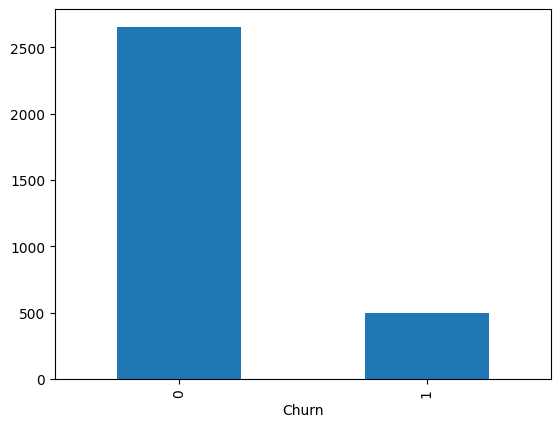

In [ ]:
df['Churn'].value_counts().plot(kind='bar')

O dataset é desbalanceado. Pelo plot, é possível ver que há 5.36 vezes a quantidade de pessoas na classe 0 do churn quando em comparação com a classe 1.

### <font color='#2D9CDB'>Q3) Gere a matriz de correlação entre os atributos do dataset e a variável alvo utilizando o gráfico fornecido e, com base nos valores apresentados, identifique quais atributos possuem maior correlação (positiva ou negativa) com a variável alvo, indicando quais podem ser mais relevantes para o problema de classificação.</font>

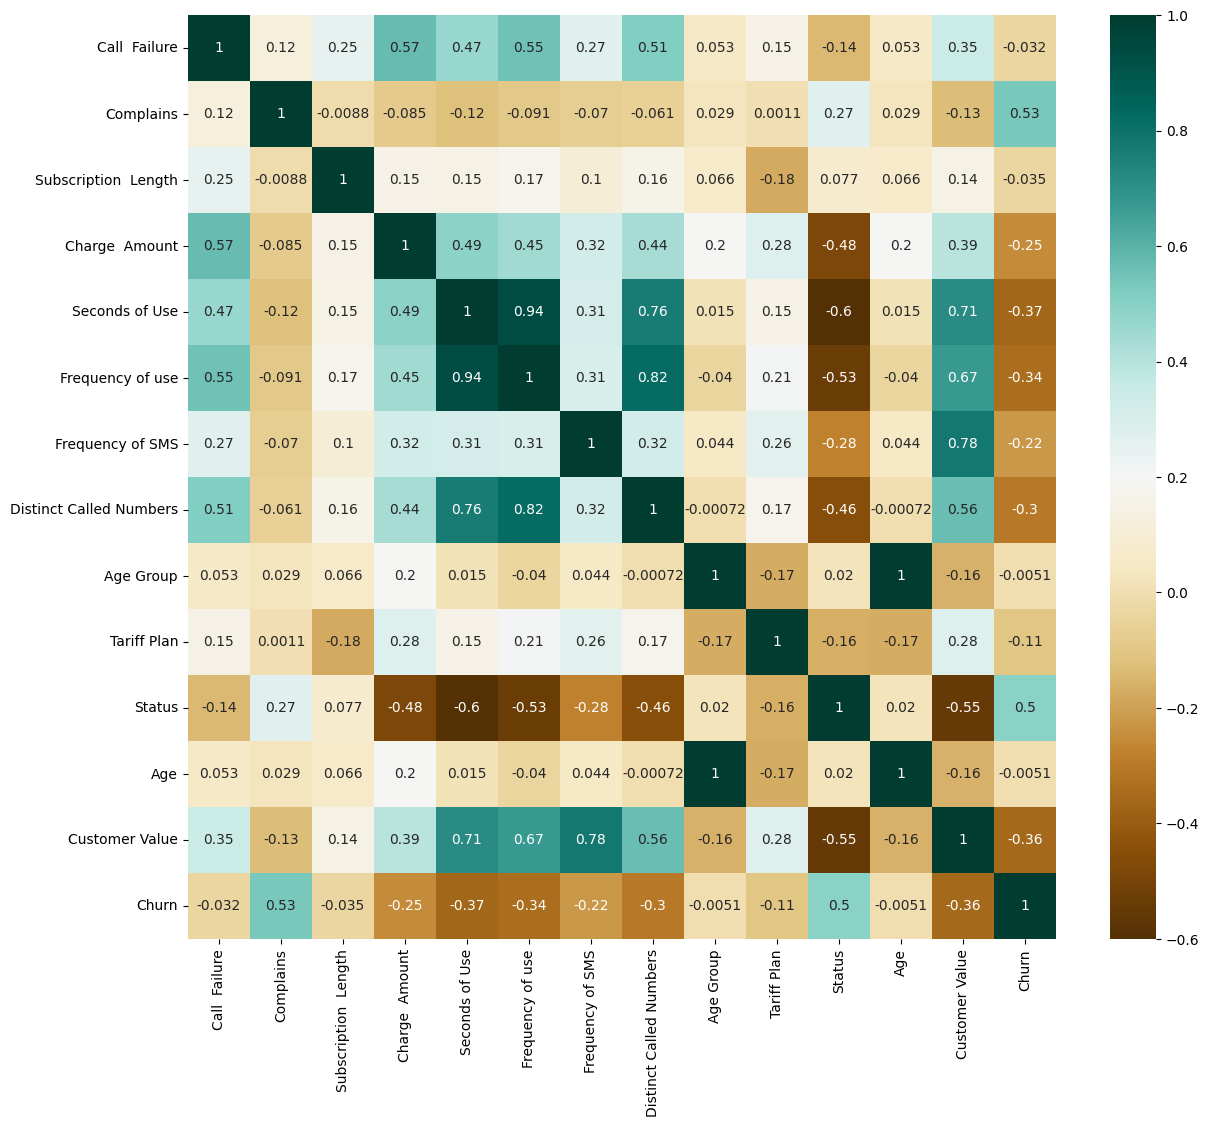

In [ ]:
corr = df.corr(method='spearman', numeric_only=True)
plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap="BrBG", annot=True)
plt.show()

In [ ]:
corr['Churn'].drop('Churn')[abs(corr['Churn'].drop('Churn'))>=0.3].sort_values(ascending=False)

,Churn
Complains,0.532053
Status,0.498976
Distinct Called Numbers,-0.301815
Frequency of use,-0.343491
Customer Value,-0.361011
Seconds of Use,-0.366818


As variáveis que possuem as correlações mais fortes com a variável alvo são aquelas que possuem uma correlação média. Dito isso, as variáveis Complains e Status possuem as correlações mais fortes e são as únicas positivas. As variáveis Distinct Called Numbers, Frequency of use, Customer Value e Seconds of Use também possuem correlação média com a variável alvo mas são correlações negativas.

### <font color='#2D9CDB'>Q4) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; antes de aplicar o PCA, padronize os dados utilizando `StandardScaler`; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

<Axes: >

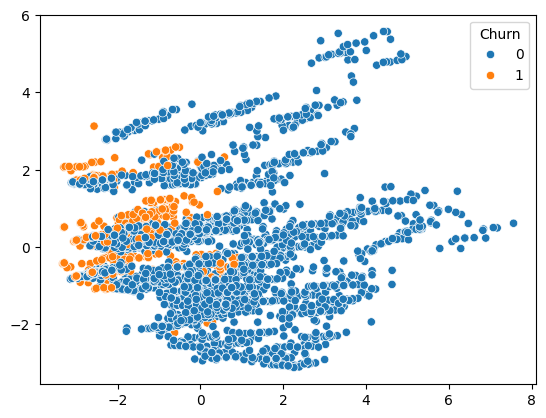

In [ ]:
# Padronizando
X = df.drop("Churn",axis=1)
y = df['Churn']
standard = StandardScaler()
X_padrao = standard.fit_transform(X)
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_padrao)
# Scatter
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df['Churn'])

**Resposta:** Além de haver um sobreposição entre os grupos, os grupos não estão separados, o que era previsto pelas correlações médias entre as variáveis. Além disso, o PCA feito com apenas 2 componentes não captura toda a variância dos dados, sendo que a sobreposição pode ser um resultado disso.

### <font color='#2D9CDB'>Q5) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, e aplique a padronização dos atributos com `StandardScaler`; em seguida, explique por que a padronização é importante nesse contexto e por que o `fit` deve ser aplicado apenas no conjunto de treino.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_padronizado = standard.fit_transform(X_train)
X_test_padronizado = standard.transform(X_test)

**Resposta:** A padronização é importante para que o código entenda como os dados se comportam em uma mesma escala. O fit deve ser aplicado apenas no treino pois deve-se evitar o Data Leekage, que é quando o modelo aprende já com dados futuros

### <font color='#2D9CDB'>Q6) Treine um modelo de regressão logística utilizando os dados de treino (`X_train`, `y_train`) e, após o treinamento, verifique se o modelo convergiu corretamente; em seguida, descreva qual é o papel desse modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [ ]:
logistic = LogisticRegression()
logistic.fit(X_train_padronizado, y_train)
logistic.n_iter_

array([42], dtype=int32)

**Resposta:** A regressão logística tenta criar uma fronteira de divisão entre dois grupos. Nesse sentido, o modelo  aprende o comportamente das variáveis de entrada e atribui pesos a elas de acordo com a influência delas com a variável alvo e aprende uma forma de dividir ambos os grupos do Churn por uma fronteira de divisão.

### <font color='#2D9CDB'>Q7) Utilize o modelo treinado para calcular as probabilidades previstas para o conjunto de teste (`predict_proba`) e exiba algumas delas; em seguida, interprete os valores obtidos explicando o que cada coluna representa e analise se o modelo está fazendo previsões com alta ou baixa confiança, com base na proximidade dos valores de 0 e 1.</font>

In [ ]:
predicao = pd.DataFrame(logistic.predict_proba(X_test_padronizado))
predicao.sample(10)

,0,1
564,0.951828,0.048172
289,0.913815,0.086185
235,0.999496,0.000504
596,0.901172,0.098828
537,0.996371,0.003629
120,0.999454,0.000546
84,0.990614,0.009386
602,0.996177,0.003823
259,0.939499,0.060501
416,0.168072,0.831928


**Resposta:** Os valores obtidos são as probabilidades de a amostra pertencer ao grupo 0 ou 1. Com base nas previsões e na proximidade da probabilidade para 1 para os grupos 0 ou 1, o modelo está fazendo as previsões com alta confiança. Além disso, essas probabilidades serem mais altas para o grupo 0 é algo visto anteriormente ao perceber que a maior parte dos dados está no grupo 0.

### <font color='#2D9CDB'>Q8) Utilize as probabilidades previstas para gerar classificações com dois limiares diferentes (0.5 e 0.7) e compare os resultados obtidos; em seguida, analise como a alteração do limiar afeta as previsões do modelo, especialmente em relação à quantidade de falsos positivos e falsos negativos.</font>

In [ ]:
predicao['limiar 0.5'] = np.where(predicao[1]>0.5, 1, 0)
predicao['limiar 0.7'] = np.where(predicao[1]>0.7, 1, 0)
predicao.sample(10)

,0,1,limiar 0.5,limiar 0.7
80,0.996463,0.003537,0,0
559,0.988243,0.011757,0,0
338,0.968196,0.031804,0,0
505,0.997533,0.002467,0,0
74,0.593470,0.406530,0,0
324,0.649761,0.350239,0,0
25,0.559244,0.440756,0,0
20,0.994277,0.005723,0,0
221,0.999225,0.000775,0,0
156,0.411869,0.588131,1,0


In [ ]:
predicao[['limiar 0.5', 'limiar 0.7']][predicao[['limiar 0.5', 'limiar 0.7']]==1].count()

,0
limiar 0.5,60
limiar 0.7,42


**Resposta:** A mudança no limiar afeta como é classificado a amostra. No 1° caso, caso a probabilidade fosse até 0.5 ela seria classificada como 0 e acima seria classificado como 1. No 2° caso, caso a probabilidade for até 0.7 ela será classificada como do grupo 0 e acima disso será classificada como do grupo 1. Dito isso, o limiar de 0.5 é um limiar mais liberal, aceitando mais que o limiar de 0.7, o que indica que o limiar de 0.5 é mais propenso a ter falsos positivos e o limiar de 0.7 a ter falsos negativos.

### <font color='#2D9CDB'>Q9) Calcule as métricas de desempenho (acurácia, precisão, recall e F1-score) e a matriz de confusão para os dois limiares de decisão (0.5 e 0.7) utilizando a função fornecida e, com base nos resultados obtidos, compare o desempenho do modelo, identificando qual métrica foi mais impactada pela mudança do limiar e discutindo o trade-off observado entre precisão e recall.</font>

In [ ]:
print('Para o limiar de 0.5:')
print(f'Matriz de confusão:\n {confusion_matrix(y_test, predicao['limiar 0.5'])}')
print(f'Acurácia: {accuracy_score(y_test,predicao['limiar 0.5'])}')
print(f'Precisão: {precision_score(y_test,predicao['limiar 0.5'])}')
print(f'Recall: {recall_score(y_test,predicao['limiar 0.5'])}')
print(f'F1 Score: {f1_score(y_test,predicao['limiar 0.5'])}\n')
print('Para o limiar de 0.7:')
print(f'Matriz de confusão:\n {confusion_matrix(y_test, predicao['limiar 0.7'])}')
print(f'Acurácia: {accuracy_score(y_test,predicao['limiar 0.7'])}')
print(f'Precisão: {precision_score(y_test,predicao['limiar 0.7'])}')
print(f'Recall: {recall_score(y_test,predicao['limiar 0.7'])}')
print(f'F1 Score: {f1_score(y_test,predicao['limiar 0.7'])}')

Para o limiar de 0.5:
Matriz de confusão:
 [[504  16]
 [ 66  44]]
Acurácia: 0.8698412698412699
Precisão: 0.7333333333333333
Recall: 0.4
F1 Score: 0.5176470588235295

Para o limiar de 0.7:
Matriz de confusão:
 [[514   6]
 [ 74  36]]
Acurácia: 0.873015873015873
Precisão: 0.8571428571428571
Recall: 0.32727272727272727
F1 Score: 0.47368421052631576


**Resposta:** Dado as métricas, o limiar de 0.5 em relação ao limiar de 0.7 erra mais em Verdadeiros Negativos, porém acerta mais em Verdadeiros Positivos. Dito isso, a acurácia do modelo com limiar 0.5 é maior que a acurácia para o modelo com limiar de 0.7, porém o F1 score é inverso, dado o numéro de Falsos Negativos e Falsos Positivos que é maior em um quando comparado com o outro.

# <font color='green'><u><b>Parte 2 - Classificação Multiclasse</b></u></font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Blackard, J. (1998). Covertype Dataset. UCI Machine Learning Repository.</font>
  - #### <font color='#2D9CDB'>https://doi.org/10.24432/C50K5N</font>
  - #### <font color='#2D9CDB'>https://archive-beta.ics.uci.edu/dataset/31/covertype</font>

A base de dados é do domínio de biologia e possui informações de variáveis cartográficas e atributos florestais. O objetivo da base é classificação, sendo usado para estudo de algortimo de classificação multiclasse. Ela possui informações categóricas e numéricas, como elevação, aspecto, declive, etc. A variável alvo desse dataset é Cover Type, variável que classifica qual o tipo de vegetação ela cada amostra se classifica como.

In [ ]:
# fetch dataset
ds = fetch_ucirepo(id=31)

# metadata
display(ds.metadata)

# variable information
display(ds.variables)

# data (as pandas dataframe)
df = pd.concat([ds.data.features, ds.data.targets], axis='columns').sample(frac=0.10, random_state=42)

{'uci_id': 31,
 'name': 'Covertype',
 'repository_url': 'https://archive.ics.uci.edu/dataset/31/covertype',
 'data_url': 'https://archive.ics.uci.edu/static/public/31/data.csv',
 'abstract': 'Classification of pixels into 7 forest cover types based on attributes such as elevation, aspect, slope, hillshade, soil-type, and more.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 581012,
 'num_features': 54,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': [],
 'target_col': ['Cover_Type'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1998,
 'last_updated': 'Sat Mar 16 2024',
 'dataset_doi': '10.24432/C50K5N',
 'creators': ['Jock Blackard'],
 'intro_paper': None,
 'additional_info': {'summary': 'Predicting forest cover type from cartographic variables only (no remotely sensed data).  The actual forest cover type for a given observation (30 x 30 meter cell

,name,role,type,demographic,description,units,missing_values
0,Elevation,Feature,Integer,None,None,None,no
1,Aspect,Feature,Integer,None,None,None,no
2,Slope,Feature,Integer,None,None,None,no
3,Horizontal_Distance_To_Hydrology,Feature,Integer,None,None,None,no
4,Vertical_Distance_To_Hydrology,Feature,Integer,None,None,None,no
5,Horizontal_Distance_To_Roadways,Feature,Integer,None,None,None,no
6,Hillshade_9am,Feature,Integer,None,None,None,no
7,Hillshade_Noon,Feature,Integer,None,None,None,no
8,Hillshade_3pm,Feature,Integer,None,None,None,no
9,Horizontal_Distance_To_Fire_Points,Feature,Integer,None,None,None,no


### <font color='#2D9CDB'>Q10) Exiba as primeiras linhas do dataframe, verifique suas dimensões e identifique a variável alvo (`TARGET_COLUMN`), respondendo com base nos resultados obtidos: quantas amostras e atributos o dataset possui, qual é o nome da variável alvo e se o problema é de classificação binária (justifique observando os valores únicos da variável alvo).</font>

In [ ]:
df.head(10)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,Cover_Type
250728,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,1,0,0,0,0,0,1
246788,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,1,0,2
407714,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,1,0,2
25713,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,0,2
21820,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,0,2
251274,2050,284,42,170,141,192,75,201,246,255,...,0,0,0,0,0,0,0,0,1,3
52354,3004,236,5,960,95,5814,211,244,171,5713,...,0,0,0,0,0,0,0,0,0,2
246168,3232,111,10,541,78,1342,237,229,122,2270,...,0,0,0,1,0,0,0,0,0,1
477113,3141,156,6,503,72,240,228,241,147,1354,...,0,0,0,0,0,0,0,0,0,2
78834,2524,36,7,30,3,630,220,225,141,300,...,0,0,0,0,0,0,0,0,0,2


In [ ]:
df['Cover_Type'].value_counts()

,count
Cover_Type,
2,28248
1,21297
3,3607
7,2052
6,1706
5,932
4,259


In [ ]:
df.shape

(58101, 55)

In [ ]:
TARGET_COLUMN = df["Cover_Type"] # preencher

O dataset possui 58101 amostras e 55 atributos (incluindo a variável alvo), sendo Cover Type a variável alvo; trata-se de um problema de classificação multiclasse, pois essa variável assume mais de um valor(1 a 7), indicando classes diferentes de vegetação.

### <font color='#2D9CDB'>Q11) Plote a distribuição da variável alvo utilizando o gráfico fornecido e, com base no resultado obtido, analise a proporção entre as classes para determinar se o dataset é balanceado ou desbalanceado, justificando sua resposta a partir da contagem de amostras em cada classe.</font>

In [ ]:
df['Cover_Type'].value_counts(sort=False)

,count
Cover_Type,
1,21297
2,28248
3,3607
5,932
6,1706
7,2052
4,259


<Axes: xlabel='Cover_Type'>

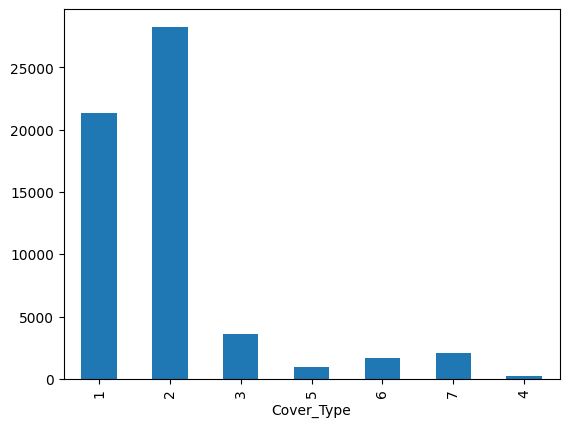

In [ ]:
df['Cover_Type'].value_counts(sort=False).plot(kind='bar')

O dataset está desbalanceado, uma vez que as classes 1 e 2 possuem cerca de 85% dos dados(ambos somam 49545 amostras do total de 58101)

### <font color='#2D9CDB'>Q12) Gere a correlação entre os atributos e a variável alvo, ordene os valores e plote um gráfico de barras horizontais; destaque, no gráfico, os atributos com maior correlação em valor absoluto utilizando linhas de referência em |r| = 0.2 (valor adotado como um limiar heurístico para indicar correlações moderadas); em seguida, com base nos resultados, identifique quais variáveis podem ser mais relevantes para o modelo. Opcionalmente, pode-se imprimir os valores de correlação para facilitar a verificação numérica dos resultados e complementar a análise visual do gráfico.</font>

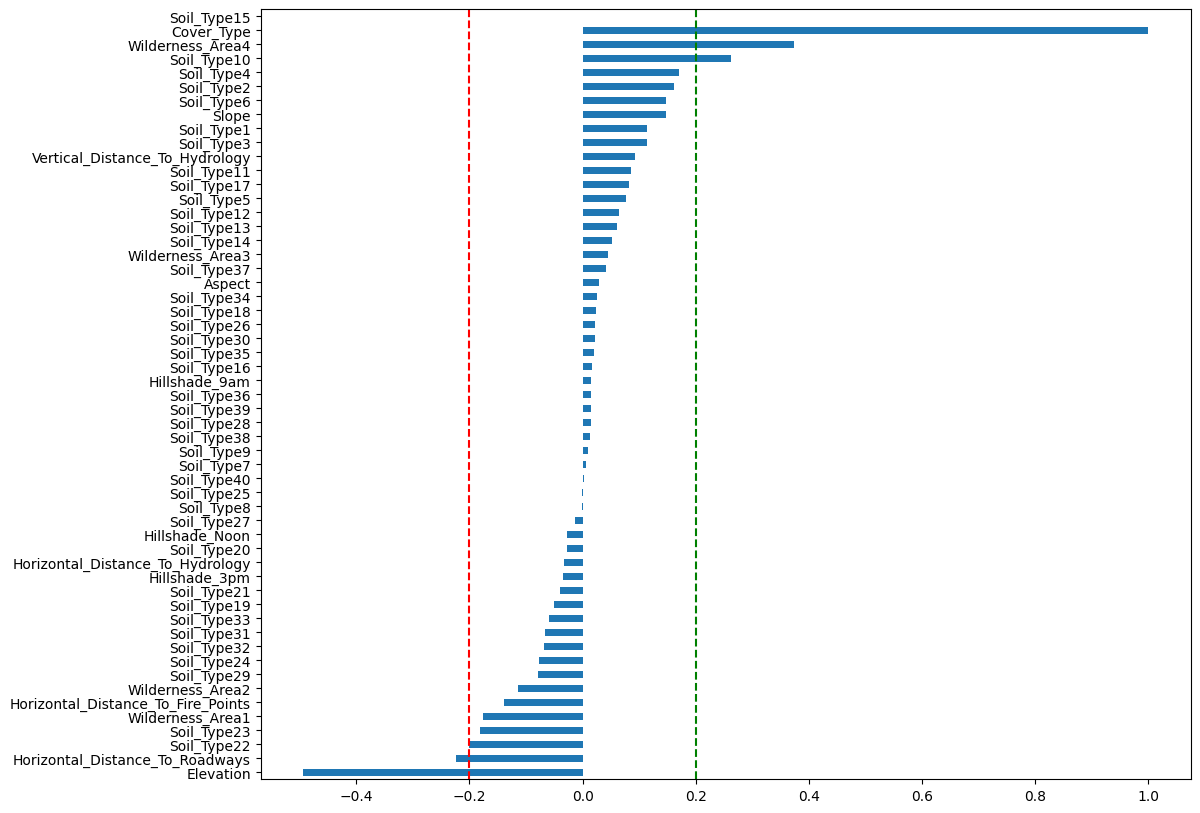

In [ ]:
corr = df.corr(method='spearman', numeric_only=True)
plt.figure(figsize=(12,10))
corr['Cover_Type'].sort_values(ascending=True).plot(kind='barh')
plt.axvline(x=-0.2, color = 'r', linestyle='--')
plt.axvline(x=0.2, color = 'g', linestyle='--')

In [ ]:
corr['Cover_Type'][abs(corr['Cover_Type'])>0.2].drop('Cover_Type')

,Cover_Type
Elevation,-0.494117
Horizontal_Distance_To_Roadways,-0.224560
Soil_Type10,0.262491
Soil_Type22,-0.201460
Wilderness_Area4,0.373605


**Resposta:** De acordo com o gráfico plotado e o auxílio dos numérico, as variáveis que podem ser mais relevantes para o modelo são as variáveis Elevation, Horizontal_Distance_To_Roadways, Soil_Type 10 e 22 e Wilderness_Area4.

### <font color='#2D9CDB'>Q13) Aplique a técnica de Análise de Componentes Principais (PCA) para projetar os dados em duas dimensões e gere um gráfico de dispersão (scatter plot) utilizando as duas primeiras componentes principais, colorindo os pontos de acordo com a variável alvo; em seguida, com base na visualização obtida, analise se há separação entre as classes e justifique sua resposta considerando a presença ou não de sobreposição entre os grupos.</font>

<Axes: >

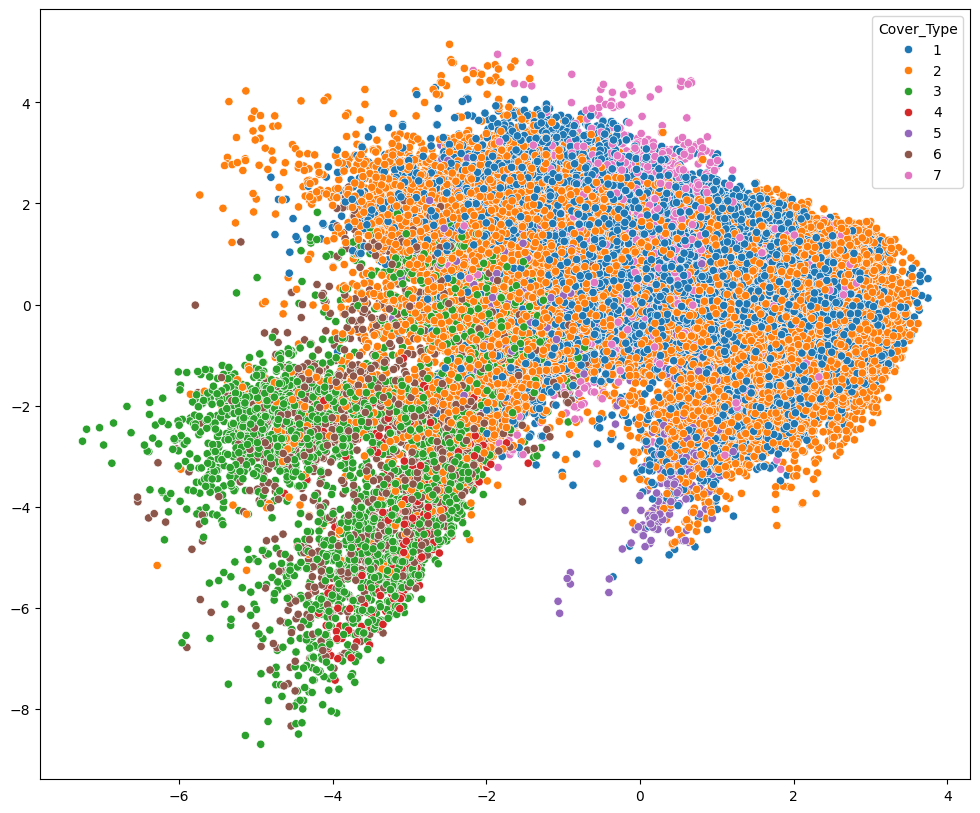

In [ ]:
# Padronizando
X = df.drop("Cover_Type",axis=1)
y = TARGET_COLUMN
standard = StandardScaler()
X_padrao = standard.fit_transform(X)
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_padrao)
# Scatter
plt.figure(figsize=(12,10))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette = 'tab10')

**Resposta:** Além de as classes se sobreporem fortemente, não há nenhuma separação visível entre as classes. Isso pode ter sido influenciado pelo fato de que o PCA feito com apenas 2 componentes não consegue capturar tão bem a variância dos dados.

A curiosidade foi mais forte que eu e eu pedi para o Claude me dar um código que plote o PCA em 3 dimensões e de forma interativa para que eu pudesse dar uma olhada.

In [ ]:
import plotly.express as px

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_padrao)

fig = px.scatter_3d(x=X_pca[:,0], y=X_pca[:,1], z=X_pca[:,2],
                    color=y.astype(str))
fig.show()

O PCA de 3 dimensões confirma o que foi deduzido em duas dimensões de uma forma melhor, há sobreposição das variáveis ainda na 3ª dimensão e não há nenhuma separação visível.

### <font color='#2D9CDB'>Q14) Separe o dataset em variáveis de entrada (`X`) e variável alvo (`y`), divida os dados em conjuntos de treino e teste utilizando `train_test_split` (com 20% para teste) e `random_state=42`, aplique a padronização dos atributos com `StandardScaler` e instancie um objeto de validação cruzada `KFold` com 5 divisões; em seguida, explique por que a validação cruzada (k-fold cross-validation) é importante para avaliar o desempenho de modelos de classificação.</font>

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_padronizado = standard.fit_transform(X_train)
X_test_padronizado = standard.transform(X_test)
kfold = KFold(n_splits=5)

**Resposta:** K-Fold é um método de validação cruzada que divide o dataset em K partes e treina o modelo K vezes, cada vez com o teste sendo uma parte diferente. Isso é importantes para testar o desempenho do modelo dado diferentes conjuntos de treinamento e teste, o que ajuda a testar o quão bem ele conseguiu generalizar.

### <font color='#2D9CDB'>Q15) Utilize o objeto `KFold` instanciado anteriormente para treinar e avaliar um modelo de regressão logística multiclasse ao longo dos 5 folds no conjunto de treino, aplicando a padronização dentro de cada fold; durante o treinamento, exiba o número de iterações (`n_iter_`) em cada fold e verifique se o modelo convergiu corretamente; em seguida, reporte a média das métricas obtidas e descreva o papel do modelo no contexto do problema e o que ele está aprendendo a partir dos dados.</font>

In [ ]:
regressao = LogisticRegression(max_iter=400)
acuracia, recall, precisao, f1 = 0.0, 0.0, 0.0, 0.0
for train_index, test_index in kfold.split(X_train, y_train):
  # Dividindo em folds:
  X_fold_train = X_train.iloc[train_index]
  X_fold_test = X_train.iloc[test_index]
  y_fold_train = y_train.iloc[train_index]
  y_fold_test = y_train.iloc[test_index]
  X_fold_train_padronizado = standard.fit_transform(X_fold_train)
  X_fold_test_padronizado = standard.transform(X_fold_test)

  # Treinando o modelo:
  regressao.fit(X_fold_train_padronizado,y_fold_train)

  #Testando o modelo:
  y_predito = regressao.predict(X_fold_test_padronizado)

  # Fazendo da iteração
  print(f'Número de iterações: {regressao.n_iter_}')
  print(f'Classification Report: \n {classification_report(y_fold_test, y_predito)}')

  #Somando as métricas:
  acuracia += accuracy_score(y_fold_test, y_predito)
  precisao += precision_score(y_fold_test, y_predito, average='macro')#Macro pra que todas as
  recall += recall_score(y_fold_test, y_predito, average='macro')# classes sejam tratadas
  f1 += f1_score(y_fold_test, y_predito, average='macro')# com peso igual

# Calculando a média das métricas:
acuracia /= 5
recall /= 5
precisao /= 5
f1 /= 5
print(f'Média da acurácia: {acuracia}')
print(f'Média do recall: {recall}')
print(f'Média da precisão: {precisao}')
print(f'Média do F1-Score: {f1}')

Número de iterações: [192]
Classification Report: 
               precision    recall  f1-score   support

           1       0.72      0.70      0.71      3469
           2       0.75      0.80      0.77      4477
           3       0.68      0.86      0.76       560
           4       0.61      0.26      0.36        43
           5       1.00      0.01      0.01       154
           6       0.55      0.28      0.37       262
           7       0.71      0.58      0.64       331

    accuracy                           0.73      9296
   macro avg       0.72      0.50      0.52      9296
weighted avg       0.73      0.73      0.72      9296

Número de iterações: [215]
Classification Report: 
               precision    recall  f1-score   support

           1       0.72      0.71      0.71      3423
           2       0.75      0.80      0.77      4510
           3       0.66      0.83      0.73       557
           4       0.62      0.36      0.46        36
           5       0.50     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



**Resposta:** Vendo pela métrica de acurácia e recall, o modelo acerta cerca de metade dos verdadeiros positivos e acerta, em média, 73% dos valores verdadeiros, negativos e positivos. Isso é esperado dado o quão pouco ele acerta das classes minoritarias como a classe 5. Dito isso, o papel do modelo é criar fronteiras de decisão entre as classes, aprendendo uma forma de separar os diferentes tipos de vegetação representados por cada classe.

### <font color='#2D9CDB'>Q16) Treine um modelo final de regressão logística utilizando todo o conjunto de treino (`X_train`, `y_train`), aplicando regularização L2 (padrão do `scikit-learn`) com `C=0.01`; em seguida, aplique a padronização adequada e utilize o modelo para calcular as probabilidades previstas no conjunto de teste (`predict_proba`); exiba algumas dessas probabilidades e interprete os valores obtidos, explicando o que cada coluna representa e analisando se o modelo está fazendo previsões com alta ou baixa confiança.</font>

In [45]:
regressao_penalidade = LogisticRegression(penalty='l2', C=0.01, max_iter=200)
regressao_penalidade.fit(X_train_padronizado, y_train)
predicao_penalidade = pd.DataFrame(regressao_penalidade.predict_proba(X_test_padronizado))
predicao_penalidade.head(10)

,0,1,2,3,4,5,6
0,0.456718,0.523084,0.000064,0.000090,0.003085,0.000088,0.016871
1,0.038392,0.450021,0.152924,0.000451,0.013272,0.344410,0.000530
2,0.224398,0.734051,0.003887,0.000330,0.021610,0.011459,0.004264
3,0.237865,0.745048,0.000941,0.000087,0.011288,0.002022,0.002749
4,0.115367,0.728307,0.007653,0.000130,0.034959,0.113243,0.000341
5,0.598901,0.389038,0.000043,0.000037,0.001486,0.000146,0.010349
6,0.386811,0.597203,0.001345,0.000070,0.004976,0.003742,0.005852
7,0.240762,0.741702,0.000431,0.000106,0.014718,0.000629,0.001651
8,0.473949,0.519709,0.000124,0.000075,0.001559,0.000342,0.004242
9,0.000430,0.049232,0.717409,0.010652,0.002515,0.219762,0.000001


**Resposta:** Cada coluna representa a probabilidade de a amostra representada por cada linha pertencer a uma das classes. Dito isso, a coluna 0 representa a classe 1, a coluna 1 representa a classe 2 e assim por diante. O modelo está predizendo com baixa confiabilidade dado que as probabilidades não chegam perto de 0.9 para uma das classes e isso se deve ao C=0.01 que penaliza fortemente os pesos do modelo.

### <font color='#2D9CDB'>Q17) Treine um modelo de regressão logística sem regularização (`penalty=None`) utilizando o mesmo procedimento de padronização e conjunto de treino; em seguida, calcule as probabilidades previstas no conjunto de teste (`predict_proba`), exiba algumas delas (usando os mesmos índices de amostras da questão anterior) e analise os resultados novamente.</font>

In [51]:
regressao_sem_penalidade = LogisticRegression(penalty=None, C=0.01, max_iter=400)
regressao_sem_penalidade.fit(X_train_padronizado, y_train)
predicao_sem_penalidade = pd.DataFrame(regressao_sem_penalidade.predict_proba(X_test_padronizado))
predicao_sem_penalidade.head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters



,0,1,2,3,4,5,6
0,4.779047e-01,0.512566,1.215503e-08,1.450274e-08,1.659997e-03,4.642122e-09,7.868828e-03
1,3.109225e-02,0.429935,1.073498e-01,1.490047e-06,1.295030e-02,4.186708e-01,2.538197e-09
2,1.993353e-01,0.775794,9.012523e-04,4.874699e-07,2.257777e-02,1.317988e-03,7.351994e-05
3,2.155095e-01,0.771856,9.517771e-07,1.472775e-07,1.239896e-02,1.371806e-04,9.732805e-05
4,1.009095e-01,0.762008,3.635516e-03,1.013747e-06,3.051376e-02,1.029321e-01,1.488697e-07
5,6.328878e-01,0.358900,4.750063e-09,9.669349e-10,6.664802e-04,4.877268e-09,7.545315e-03
6,3.876715e-01,0.607608,1.360361e-04,2.124222e-07,3.825414e-03,4.457652e-04,3.132896e-04
7,2.229160e-01,0.762972,1.361985e-07,2.278046e-11,1.401508e-02,5.441223e-08,9.657432e-05
8,4.605671e-01,0.538920,9.640051e-07,4.283471e-08,2.903764e-06,1.457271e-07,5.090766e-04
9,8.670166e-09,0.008674,7.359574e-01,1.092123e-02,1.764148e-07,2.444470e-01,2.978682e-16


**Resposta:** O modelo sem a penalização foca a probabilidade nas classes majoritárias, excluindo quase que completamente as classes minoritárias. Isso se deve ao fato de que o modelo sem nenhuma penalização foca suas predições em classes que aparecem muito nos dados, ficando enviesado a ponto de overfitting.

### <font color='#2D9CDB'>Q18) Compare as probabilidades previstas pelos modelos com e sem regularização e analise as diferenças observadas, considerando: (i) a concentração das probabilidades em uma única classe, (ii) o nível de confiança das previsões e (iii) possíveis indícios de overfitting; para apoiar sua análise, calcule a confiança média dos modelos (considerando, para cada amostra, a maior probabilidade prevista) e utilize esse valor na comparação.</font>

In [59]:
print(f'Confiança média do modelo com penalidade: {predicao_penalidade.max(axis=1).mean()}')
print(f'Confiança média do modelo sem penalidade: {predicao_sem_penalidade.max(axis=1).mean()}')

Confiança média do modelo com penalidade: 0.7024909029483848
Confiança média do modelo sem penalidade: 0.7275706595353355


**Resposta:** Enquanto o modelo com penalidade possui uma confiabilidade menor que o modelo sem penalidade, ele ainda leva em consideração as classes minoritárias, havendo uma distribuição maior de probabilidade entre as 7 classes, enquanto o modelo sem penalidade foca apenas nas duas classes majoritárias, distribuindo a probabilidade entre ambas. O nível de confiança do modelo com penalidade é baixo, uma vez que suas probabilidades para uma única classe não chegam nem a 0.9, o mesmo não pode ser dito para o modelo sem penalidade, uma vez que a probabilidade está majoritariamente nas classes majoritárias. Enquanto o modelo com penalidade indica uma boa generalização, o modelo sem penalidade traz indícios de overfitting, visto que ele ficou enviesado as classes majoritárias, causando um possível overfitting.

### <font color='#2D9CDB'>Q19) Utilize o `classification_report` para avaliar o desempenho dos modelos com e sem regularização no conjunto de teste; em seguida, compare os resultados obtidos, analisando as métricas de precisão, recall e F1-score para cada classe e discutindo possíveis diferenças no desempenho entre os modelos.</font>

In [65]:
print(f'Com penalidade: \n {classification_report(y_test,regressao_penalidade.predict(X_test_padronizado))}')
print(f'Sem penalidade: \n {classification_report(y_test,regressao_sem_penalidade.predict(X_test_padronizado))}')

Com penalidade: 
               precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.75      0.81      0.78      5759
           3       0.62      0.84      0.71       720
           4       0.40      0.11      0.17        55
           5       1.00      0.01      0.01       178
           6       0.51      0.12      0.20       339
           7       0.67      0.52      0.58       407

    accuracy                           0.72     11621
   macro avg       0.67      0.44      0.45     11621
weighted avg       0.72      0.72      0.71     11621

Sem penalidade: 
               precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.76      0.80      0.78      5759
           3       0.64      0.79      0.71       720
           4       0.58      0.35      0.43        55
           5       0.50      0.01      0.01       178
           6       0.47      0.22      0.3

**Resposta:** O modelo com penalidade mostra um conservadorismo ao classificar as classes minoritárias, como é possível analisar pela classe 5, onde ele acerta sempre que diz ser classe 5, mas deixa passar muitas dela, o que significa que ele apenas afirma quando tem certeza. Além disso, ao analisar as classes 4 e 6 dos modelos, é possível ver que o modelo sem regularização acerta mais nessas classes, o que provavelmente se deve ao fato de a penalidade do modelo com regularização ser forte, causando um underfitting por não conseguir generalizar bem o suficiente. Dito isso, o ideal talvez fosse treinar um modelo com uma penalização intermediária que talvez conseguisse generalizar melhor que ambos os modelos.

### <font color='#2D9CDB'>Q20) Calcule a matriz de confusão normalizada (por linha, com duas casas de precisão) para os modelos com e sem regularização no conjunto de teste; em seguida, plote ambas as matrizes e compare os resultados, analisando quais classes são melhor classificadas, quais apresentam maior confusão e como a regularização impacta o desempenho entre as classes.</font>

<Axes: title={'center': 'Modelo sem penalidade'}>

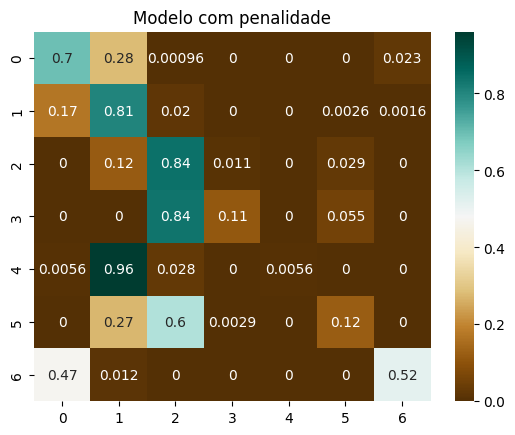

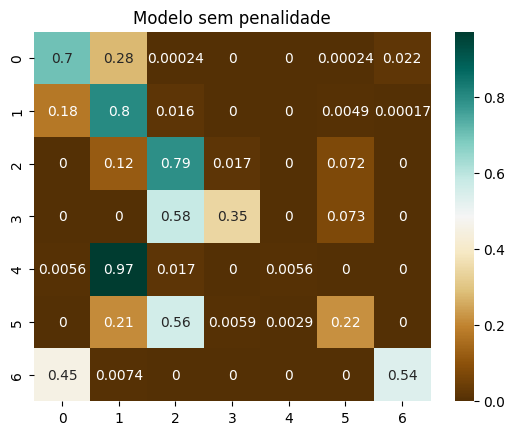

In [78]:
matriz_modelo_penalidade = pd.DataFrame(confusion_matrix(y_test,regressao_penalidade.predict(X_test_padronizado), normalize='true'))
matriz_modelo_sem_penalidade = pd.DataFrame(confusion_matrix(y_test,regressao_sem_penalidade.predict(X_test_padronizado), normalize='true'))
plt.figure()
plt.title('Modelo com penalidade')
sns.heatmap(matriz_modelo_penalidade, cmap='BrBG', annot=True)
plt.figure()
plt.title('Modelo sem penalidade')
sns.heatmap(matriz_modelo_sem_penalidade, cmap='BrBG', annot=True)

**Resposta:** As classes mais bem identificadas são as classes 1, 2 e 3 em ambos os modelos e as que causam mais confusão são as classes 4, 5 e 6. Além disso, a regularização fez com que o modelo só afirmasse que a amostra era da classe menoritária quando ele tinha certeza disso, o que fez com que o modelo não acertasse quase nada dessas classes menoritárias. Além disso, ambos modelos confundem a classe 5 com a classe 2, o que pode indicar uma similaridade muito alta entre ambas classes.

## Questão extra:
Na questão 19 eu cheguei na conclusão de que talvez o ideal fosse treinar um modelo com um C intermediário, que não penalizasse nem muito nem pouco, então, para fins de comprovação, vou testar essa hipótese.


### Treinando o modelo intermediário

In [84]:
regressao_penalidade_intermediaria = LogisticRegression(penalty='l2', C=1, max_iter=200)
regressao_penalidade_intermediaria.fit(X_train_padronizado, y_train)
predicao_penalidade_intermediaria = pd.DataFrame(regressao_penalidade_intermediaria.predict_proba(X_test_padronizado))
predicao_penalidade_intermediaria.head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



,0,1,2,3,4,5,6
0,4.772080e-01,0.512930,7.687907e-08,2.069669e-07,0.001654,4.356308e-08,8.207559e-03
1,3.126833e-02,0.435543,1.151478e-01,8.047922e-06,0.013662,4.043712e-01,2.888933e-08
2,1.995240e-01,0.773971,1.186759e-03,1.775407e-06,0.023329,1.902713e-03,8.473661e-05
3,2.155826e-01,0.772449,3.997464e-06,3.132426e-07,0.011668,1.788832e-04,1.178596e-04
4,9.922714e-02,0.752545,3.671467e-03,2.961322e-06,0.030167,1.143860e-01,3.616039e-07
5,6.326878e-01,0.358951,3.106937e-08,1.901739e-08,0.000671,4.925474e-08,7.690169e-03
6,3.870624e-01,0.607945,1.947234e-04,5.270847e-07,0.003893,5.590563e-04,3.450856e-04
7,2.235909e-01,0.762670,8.260068e-07,1.301951e-09,0.013628,4.881903e-07,1.097162e-04
8,4.615908e-01,0.537845,1.174974e-06,6.667233e-08,0.000025,3.878117e-07,5.379271e-04
9,5.397125e-07,0.010096,7.406435e-01,1.311405e-02,0.000012,2.361338e-01,1.265345e-14


Analisando as probabilidades, o modelo intermediário continua tendo uma confiabilidade baixa, um pouco mais alto que o modelo com regularização alta, mas ainda baixo, porém ele também distribui mais as probabilidades entre as classes minoritárias, menos do que o com alta regularização, porém, mais que o sem nenhuma regularização.

### Calculando as métricas

In [82]:
print(f'Penalidade alta: \n {classification_report(y_test,regressao_penalidade.predict(X_test_padronizado))}')
print(f'Penalidade média: \n {classification_report(y_test,regressao_penalidade_intermediaria.predict(X_test_padronizado))}')
print(f'Sem penalidade: \n {classification_report(y_test,regressao_sem_penalidade.predict(X_test_padronizado))}')

Penalidade alta: 
               precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.75      0.81      0.78      5759
           3       0.62      0.84      0.71       720
           4       0.40      0.11      0.17        55
           5       1.00      0.01      0.01       178
           6       0.51      0.12      0.20       339
           7       0.67      0.52      0.58       407

    accuracy                           0.72     11621
   macro avg       0.67      0.44      0.45     11621
weighted avg       0.72      0.72      0.71     11621

Penalidade média: 
               precision    recall  f1-score   support

           1       0.71      0.70      0.70      4163
           2       0.76      0.80      0.78      5759
           3       0.64      0.80      0.71       720
           4       0.59      0.31      0.40        55
           5       0.50      0.01      0.01       178
           6       0.50      0.22      

Pelo classification report, conseguimos ver que a penalidade média possui métricas melhores que a penalidade alta, como uma acurácia geral mais alta e médias macro de recall e f1-score mais altos, o que indica que uma liberdade maior ajudou a entender os padrões. Em comparação com a sem penalidade, a penalidade média possui a mesma acurácia, porém com médias macro de precisão, recall e f1-score um pouco menores. Dito isso, as métricas para as classes 4 e 6 da penalidade média são melhores que as da penalidade alta e comparáveis com a sem penalidade, o que indica que o modelo com penalidade média consegue identificar padrões melhor que a penalidade alta, porém ainda levando as classes minoritárias em conta, diferente do modelo sem penalidade.

<Axes: title={'center': 'Modelo sem penalidade'}>

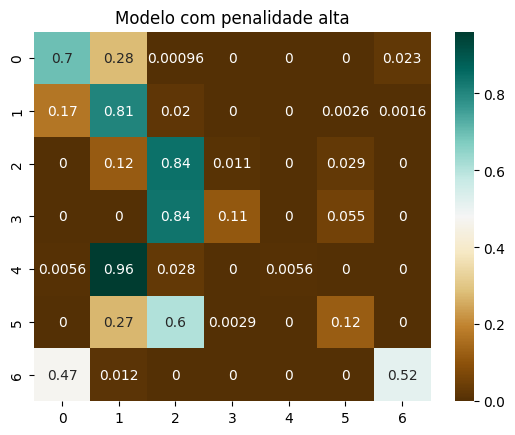

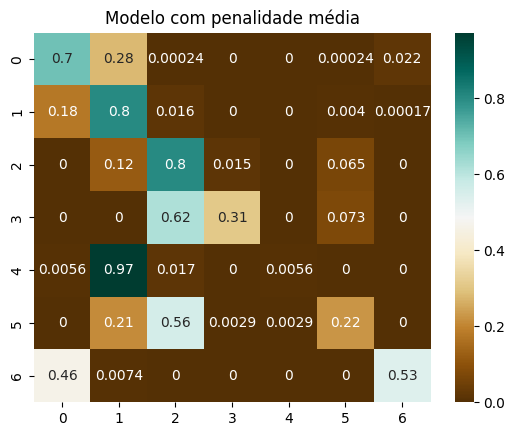

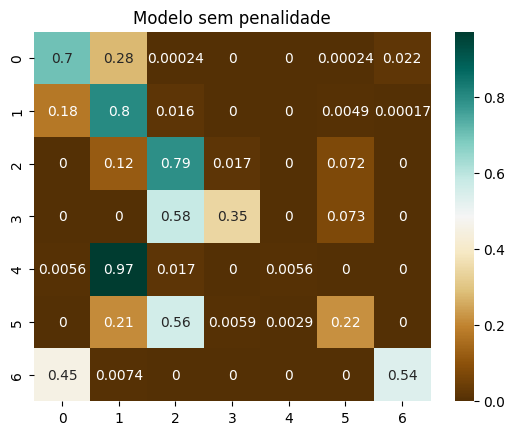

In [83]:
matriz_modelo_penalidade = pd.DataFrame(confusion_matrix(y_test,regressao_penalidade.predict(X_test_padronizado), normalize='true'))
plt.figure()
plt.title('Modelo com penalidade alta')
sns.heatmap(matriz_modelo_penalidade, cmap='BrBG', annot=True)
matriz_modelo_penalidade_media = pd.DataFrame(confusion_matrix(y_test,regressao_penalidade_intermediaria.predict(X_test_padronizado), normalize='true'))
plt.figure()
plt.title('Modelo com penalidade média')
sns.heatmap(matriz_modelo_penalidade_media, cmap='BrBG', annot=True)
matriz_modelo_sem_penalidade = pd.DataFrame(confusion_matrix(y_test,regressao_sem_penalidade.predict(X_test_padronizado), normalize='true'))
plt.figure()
plt.title('Modelo sem penalidade')
sns.heatmap(matriz_modelo_sem_penalidade, cmap='BrBG', annot=True)

Pela matriz de confusão, percebe-se que o modelo com penalidade média possui uma diagonal principal melhor que a diagonal principal do modelo com penalidade alta e confusões gerais um pouco mais baixo, sendo possível perceber que a penalidade alta impedia o modelo de encontrar a fronteira de decisão entre as classes 3 e 4, visto a melhora nas métricas. Em comparação com a sem penalidade, o modelo com penalidade média possui um diagonal principal comparável, porém com confusões gerais mais baixas, quando visto, por exemplo, com a classe 3, onde o acerto na penalidade média é de 0.80 com confusão de 0.065 na classe 6 e no modelo com penalidade, o acerto desce para 0.79 e a confusão com a classe 6 sobe para 0.072, o que indica que a penalidade consegue filtrar o ruído melhor que sem a penalidade.

### Conclusões finais
O modelo com a penalidade intermediária realmente é melhor para esse dataset que o modelo sem penalidade e o modelo com penalidade alta. Enquanto a penalidade alta causa um underfitting severo nas classes minoritárias, o modelo sem penalidade não apresenta ganhos significativos de acurácia que justifiquem a perda de regularização. Oferecendo, então, uma predição que consegue manter as métricas das classes majoritárias e apresenta uma diagonal principal mais robusta nas classes 3, 4 e 6 em comparação ao modelo altamente penalizado

Dito isso, ele ser melhor ainda não significa que ele é bom. O ideal para esse problema seria aumentar o número de dados das classes minoritárias, o que ajudaria o modelo a generalizar melhor.